In [27]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random
import time
from IPython.display import clear_output

### Source Environment
https://gymnasium.farama.org/environments/toy_text/taxi/

In [ ]:
# Create the Taxi environment with render_mode set for viewing in the notebook
env = gym.make("Taxi-v3", render_mode="rgb_array")

In [29]:
# Initialize Q-table with zeros for all state-action pairs.
# The environment specifies observation_space.n and action_space.n.
q_table = np.zeros((env.observation_space.n, env.action_space.n))

In [ ]:
# Hyperparameters
num_episodes = 2000        # Total training episodes
max_steps = 30             # Maximum steps per episode
learning_rate = 0.8        # Learning rate (alpha)
gamma = 0.95               # Discount factor for future rewards
epsilon = 1.0              # Starting epsilon for ε-greedy policy (exploration rate)
max_epsilon = 1.0          # Maximum exploration probability at start
min_epsilon = 0.01         # Minimum exploration probability
decay_rate = 0.005         # Exponential decay rate for exploration prob

In [31]:
# List to hold rewards for each episode (we'll use it later for plotting)
rewards = []
epsilon_history = []

In [32]:
def display_subplots(rewards, epsilon_history, episode, frame):
    """
    Creates a figure with three vertically arranged subplots:
      - The top subplot displays the reward curve.
      - The middle subplot shows the epsilon decay.
      - The bottom subplot shows the current demo frame.
    """
    clear_output(wait=True)
    fig, axs = plt.subplots(3, 1, figsize=(10, 12), 
                            gridspec_kw={'height_ratios': [1, 1, 2]})
    
    # Top subplot: Reward curve.
    axs[0].plot(rewards, label="Reward per Episode", color="blue")
    axs[0].set_xlabel("Episode")
    axs[0].set_ylabel("Reward")
    axs[0].set_title(f"Training Progress (Up to Episode {episode})")
    axs[0].legend()
    axs[0].grid(True)
    
    # Middle subplot: Epsilon decay.
    axs[1].plot(epsilon_history, label="Epsilon Value", color="red")
    axs[1].set_xlabel("Episode")
    axs[1].set_ylabel("Epsilon")
    axs[1].set_title("Epsilon Decay")
    axs[1].legend()
    axs[1].grid(True)
    
    # Bottom subplot: Agent demo render.
    axs[2].imshow(frame)
    axs[2].set_title("Demo Episode")
    axs[2].axis("off")
    
    plt.tight_layout()
    plt.show()

In [33]:
def demo_episode(q_table, current_episode, epsilon_history, max_steps, sleep_time=0.5):
    """
    Runs a demonstration episode using the current Q-table.
    For each step, it updates a figure with the current reward curve (above)
    and the current rendered frame from the environment (below).
    """
    state, info = env.reset()
    done = False
    step = 0
    while True and step < max_steps:
        step += 1
        # Select the best known action.
        action = np.argmax(q_table[state, :])
        state, reward, done, truncated, info = env.step(action)
        
        # Capture the current frame.
        frame = env.render()
        
        # Update the subplots to show both the reward curve and the current frame.
        display_subplots(rewards, epsilon_history, current_episode, frame)
        time.sleep(sleep_time)
        
        if done or truncated:
            print("Demo finished!")
            break

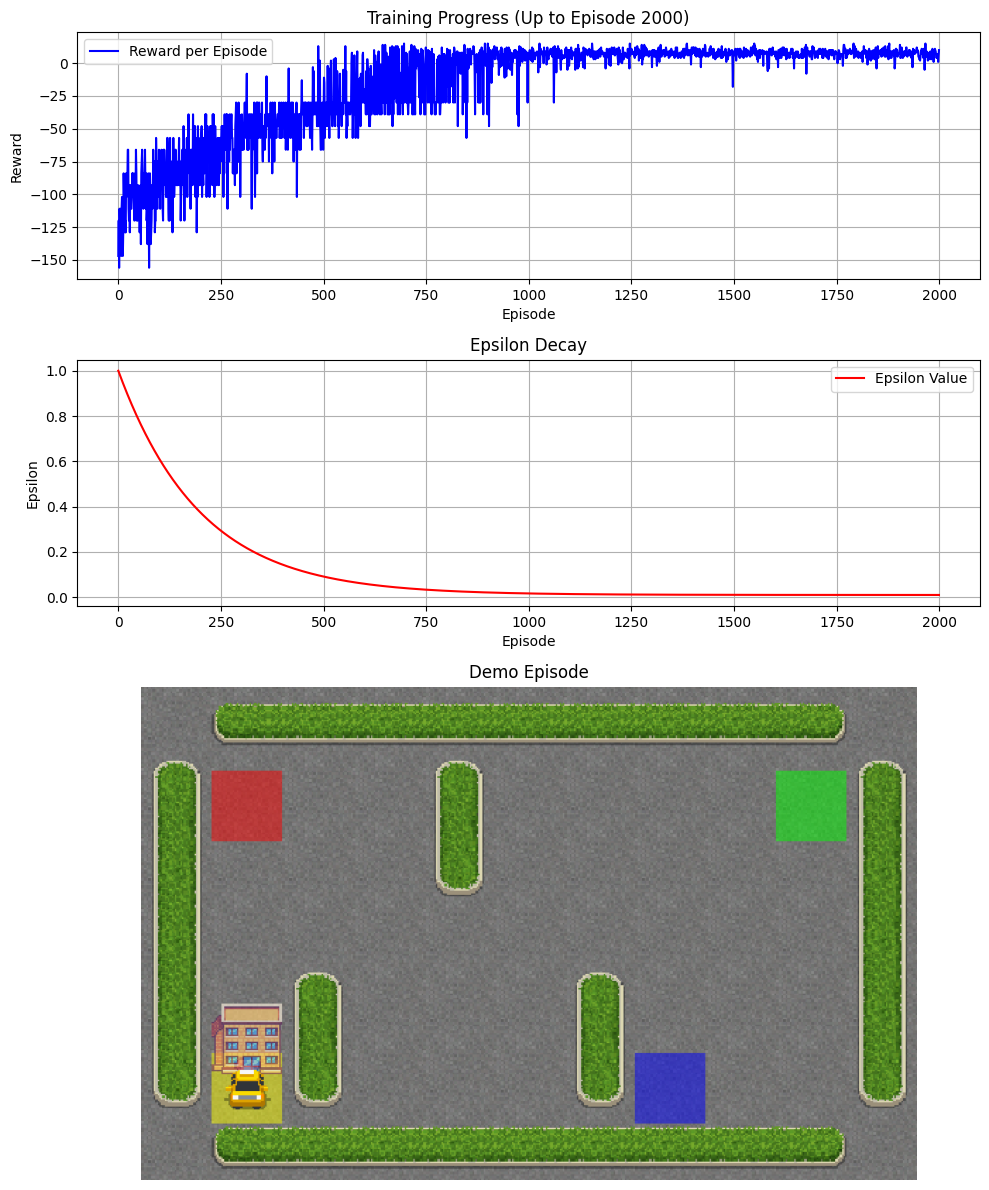

Demo finished!


In [34]:
# Q-learning Training Loop
for episode in range(num_episodes):
    state, info = env.reset()   # Reset the environment for a new episode
    total_reward = 0
    done = False

    for step in range(max_steps):
        # Choose an action using the ε-greedy strategy
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()  # Explore: random action
        else:
            action = np.argmax(q_table[state, :])  # Exploit: best known action

        # Take the action and observe the next state and reward
        new_state, reward, done, truncated, info = env.step(action)

        # Q-learning update rule:
        # Q(s,a) = Q(s,a) + α [r + γ max_a' Q(s', a') - Q(s,a)]
        q_table[state, action] = q_table[state, action] + learning_rate * (
            reward + gamma * np.max(q_table[new_state, :]) - q_table[state, action]
        )

        state = new_state  # Transition to new state
        total_reward += reward

        if done or truncated:
            break

    # Decay epsilon after each episode to reduce exploration over time
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)
    rewards.append(total_reward)
    epsilon_history.append(epsilon)

    # Run a demonstration episode every 100 training episodes.
    if (episode + 1) % 100 == 0:
        print(f"\nEpisode {episode + 1} demonstration:")
        demo_episode(q_table, episode + 1, epsilon_history, max_steps=max_steps, sleep_time=0.05)

In [35]:
# Training complete. Display the learned Q-table.
print("Trained Q-table:")
print(q_table)

Trained Q-table:
[[  0.           0.           0.           0.           0.
    0.        ]
 [ -6.87662908  -6.70334728  -6.80176761  -6.70334728   5.20997639
  -13.37799833]
 [ -3.74155182  -3.69254605  -4.10043097  -3.72690583  10.9512375
   -1.2770595 ]
 ...
 [ -3.8284415   -3.40199629  -3.86214357  -3.5146326  -11.77682944
  -10.3296    ]
 [ -3.18293811  -3.38417459  -3.69254605  -3.61302335 -10.9317632
  -10.208     ]
 [ -1.568       -1.568       -1.7216      17.84832     -8.
   -8.        ]]


In [11]:
env.close()  # Close the environment